# 数据集介绍
鸢尾花数据集：150个样本

# 导入数据

In [1]:
# 导入类库
from pandas import read_csv

from pandas.plotting import scatter_matrix
from matplotlib import pyplot

from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [2]:
# 导入数据
filename='iris.data.csv' # 路径中不能有中文
names = ['separ-length',  'separ-width',  'petal-length',  'petal-width',   'class']

dataset=read_csv(filename, names=names)

# 概述数据

In [3]:
#显示数据维度
print('数据维度: 行 %s，列 %s' % dataset.shape) # 占位符表示

数据维度: 行 150，列 5


In [4]:
print(dataset.shape)

(150, 5)


In [5]:
# 查看数据的前10行
print(dataset.head(10))
print(dataset.tail(10)) # 后10行也可以，.tail

   separ-length  separ-width  petal-length  petal-width        class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
5           5.4          3.9           1.7          0.4  Iris-setosa
6           4.6          3.4           1.4          0.3  Iris-setosa
7           5.0          3.4           1.5          0.2  Iris-setosa
8           4.4          2.9           1.4          0.2  Iris-setosa
9           4.9          3.1           1.5          0.1  Iris-setosa
     separ-length  separ-width  petal-length  petal-width           class
140           6.7          3.1           5.6          2.4  Iris-virginica
141           6.9          3.1           5.1          2.3  Iris-virginica
142           5.8  

In [6]:
# 统计描述数据信息
print(dataset.describe())

       separ-length  separ-width  petal-length  petal-width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [6]:
# 分类分布情况
print(dataset.groupby("class").size())
print(dataset.groupby("class"))

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


# 数据可视化

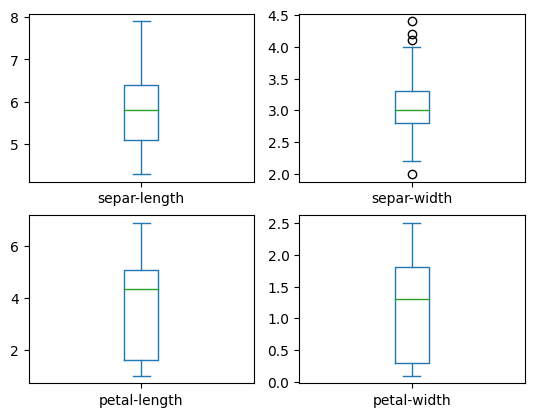

<Figure size 640x480 with 0 Axes>

In [8]:
# 箱线图
dataset.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)
pyplot.savefig("hello_box.png")
pyplot.show()

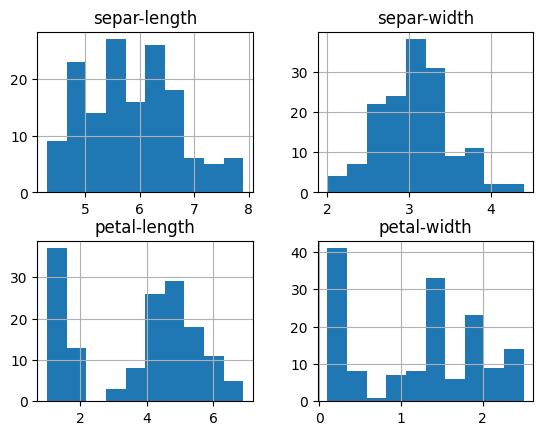

In [9]:
# 直方图
dataset.hist()
pyplot.show()

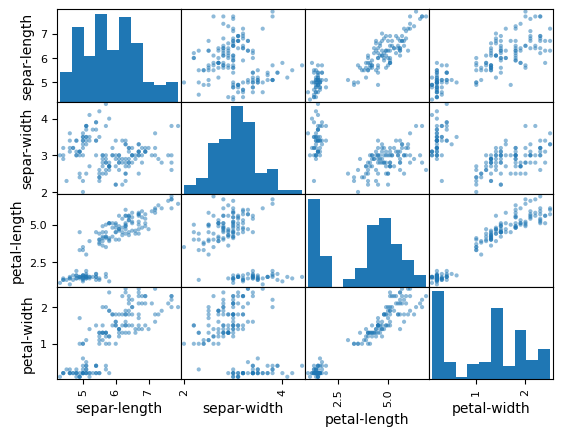

In [10]:
# 散点矩阵图
scatter_matrix(dataset)
pyplot.show()

# 评估算法

In [10]:
# 分离数据集
array=dataset.values
X=array[:, 0:4]
Y=array[:, 4]
validation_size=0.2
seed=7
X_train, X_validation, Y_train, Y_validation=\
        train_test_split(X, Y, test_size=validation_size,
        random_state=seed)

In [13]:
# import warnings
# warnings.filterwarnings('ignore')

# 算法审查
models = {}
models['LR'] = LogisticRegression()
models['LDA'] = LinearDiscriminantAnalysis()
models['KNN'] = KNeighborsClassifier()
models['CART'] = DecisionTreeClassifier()
models['NB'] = GaussianNB()
models['SVM'] = SVC()

# 评估算法
results = []
for key in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=seed)
    cv_results = cross_val_score(models[key], X_train, Y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    print('%s: %f (%f)' % (key, cv_results.mean(), cv_results.std()))

LR: 0.983333 (0.033333)
LDA: 0.975000 (0.038188)
KNN: 0.983333 (0.033333)
CART: 0.950000 (0.076376)
NB: 0.966667 (0.040825)
SVM: 0.983333 (0.033333)


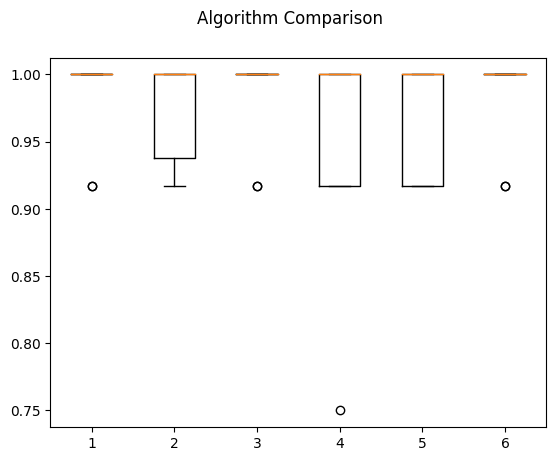

In [13]:
# 箱线图比较算法
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)

# ax.set_xticklabels(models.keys())
# pyplot.ylim(0.85, 1.00)
pyplot.show()

# 使用评估数据集评估算法

In [15]:
# 使用评估数据集评估算法
svm=SVC()
svm.fit(X=X_train, y=Y_train)
predictions=svm.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.8666666666666667
[[ 7  0  0]
 [ 0 10  2]
 [ 0  2  9]]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.83      0.83      0.83        12
 Iris-virginica       0.82      0.82      0.82        11

       accuracy                           0.87        30
      macro avg       0.88      0.88      0.88        30
   weighted avg       0.87      0.87      0.87        30

